# Part 4: Query entity embeddings in Gensim

This notebook illustrates how to query the entity embedding model in `gensim.Word2Vec`

Based on a tutorial presented for GraphGeeks.org on 2024-08-14

In [1]:
import gensim
import matplotlib.pyplot as plt
import pandas as pd

W2V_MODEL: str = "data/entity.w2v"

w2v_model: gensim.models.Word2Vec = gensim.models.Word2Vec.load(W2V_MODEL)

In [2]:
query: str = "NOUN.dementia"

In [3]:
df: pd.DataFrame = pd.DataFrame([
    {
        "entity": neighbor[0],
        "distance": neighbor[1],
    }
    for neighbor in w2v_model.wv.most_similar(positive = [ query ], topn = 10)
    if neighbor[1] > 0.0
])

df

,entity,distance
0,ADJ.rigorous ADJ.scientific NOUN.research,0.298067
1,NOUN.caution,0.240813
2,PROPN.aaic,0.226096
3,4,0.215882
4,NUM.one NOUN.way,0.204727
5,NOUN.researcher,0.198051
6,ADJ.different NOUN.amount,0.192797
7,PROPN.li,0.178712
8,NOUN.study NOUN.result,0.163757
9,NOUN.research,0.162103


Neighbors with distances approaching zero tend to be _synonyms_, while those with distances above the mean tend to be _semantically related_.

In [4]:
df.distance.mean()

0.20810049623250962

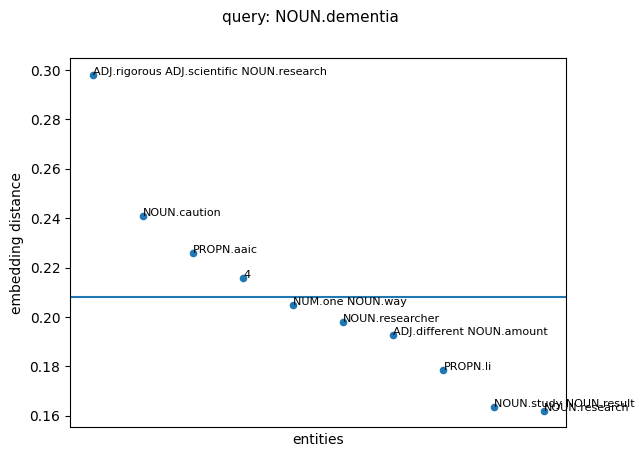

In [5]:
fig, ax = plt.subplots()

fig.suptitle(
    f"query: {query}",
    fontsize = 11,
)

df.plot(
    "entity",
    "distance",
    kind = "scatter",
    ax = ax,
)

for index, row in df.iterrows():
    ax.annotate(
        row["entity"],
        (row["entity"], row["distance"]),
        size = 8,
    )

plt.xticks([])
ax.set_xlabel("entities")
ax.set_ylabel("embedding distance")

plt.axhline(y = df.distance.mean())

plt.show()